PHASE 1

In [1]:
import pandas as pd
import glob
import os
# combine all payment(BOLT) csv files into one file and creating a dataframe
files= glob.glob(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\BOLT\bolt_payment\*.csv')
df_bolt_payments_raw = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df_bolt_payments_raw.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\BOLT\bolt_payment\bolt_payment_stacked.csv', index=False)



In [2]:
# combine all ride(BOLT) csv files into one file and creating a dataframe 
path= r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\BOLT\Order history\order_history'
files = glob.glob(path + "/**/*.csv", recursive=True)
df_bolt_trips_raw = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df_bolt_trips_raw.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\BOLT\Order history\order_history_stacked.csv', index=False)

In [3]:
# read the Uber trips csv file and creating a dataframe
path = r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\Uber\uber_trips.csv'
df_uber_trips_raw= pd.read_csv(path)

# read the Uber payments csv file and creating a dataframe
path = r"C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\Uber\uber_payments.csv"
df_uber_payments_raw= pd.read_csv(path)


In [4]:
import pyodbc
import pandas as pd

from sqlalchemy import create_engine

conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=LAMOSKI;"
    "Database=RideMetrics;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)
engine = create_engine("mssql+pyodbc://LAMOSKI/RideMetrics?driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes&encrypt=no")


cursor = conn.cursor()
cursor.execute("SELECT @@VERSION")
print(cursor.fetchone())

('Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) \n\tOct  8 2022 05:58:25 \n\tCopyright (C) 2022 Microsoft Corporation\n\tDeveloper Edition (64-bit) on Windows 10 Home 10.0 <X64> (Build 26200: ) (Hypervisor)\n',)


REMOVAL OF PRIVATE SENSITIVE COLUMNS

In [6]:
# ingesting data into Bronze schema after prunning(private sensitive data) and selecting relevant columns.
#  Also saving the prunned dataframes as csv files in the RawFiles folder for future reference.

# Bolt payment data
df_bolt_payments_bronze = df_bolt_payments_raw[['Date', 'Payment method', 'Date of ride',  'Price (no VAT)', 'VAT', 'Price Total']]
df_bolt_payments_bronze.to_sql('Bolt_Payments', engine,schema='Bronze', if_exists= 'replace', index= False )
df_bolt_payments_bronze.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\RawFiles\Bolt_Payments.csv', index=False) 

# Bolt trips data
df_bolt_trips_bronze = df_bolt_trips_raw[['Time', 'Driver accepted', 'Ride finished', 'Pickup distance', 'Ride distance', 'Ride duration', 
                               'Order state', 'Reject reason', 'Pickup duration', 
                               'Estimated pickup time', 'Estimated distance', 'Estimated duration']]
df_bolt_trips_bronze.to_sql('Bolt_Trips', engine,schema= 'Bronze', if_exists= 'replace', index=False)
df_bolt_trips_bronze.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\RawFiles\Bolt_Trips.csv', index=False) 

# Uber trips data
df_uber_trips_bronze = df_uber_trips_raw[['global_product_name', 'status', 'request_timestamp_local',
                                'begintrip_timestamp_local', 'dropoff_timestamp_local',
                                'trip_distance_miles', 'trip_duration_seconds', 'base_fare_local',
                                'original_fare_local', 'cancellation_fee_local']]
df_uber_trips_bronze.to_sql('Uber_Trips', engine,schema='Bronze', if_exists= 'replace', index= False )
df_uber_trips_bronze.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\RawFiles\Uber_Trips.csv', index=False)

# Uber payments data
df_uber_payments_bronze = df_uber_payments_raw[['City Name', 'Trip UUID', 'Local Amount', 'Currency Code',
       'Classification', 'Category', 'Local Timestamp']]
df_uber_payments_bronze.to_sql('Uber_Payments', engine,schema='Bronze', if_exists= 'replace', index= False )
df_uber_payments_bronze.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\RawFiles\Uber_Payments.csv', index=False)


PHASE 2 (REMOVAL OF UNWANTED COLUMNS)

In [7]:
# reading the data from the Bronze schema to create dataframes for further processing in Silver and Gold layers.
df_bolt_trips_silver = pd.read_sql('select * from Bronze.Bolt_Trips',engine)
df_uber_trips_silver = pd.read_sql('select * from Bronze.Uber_Trips',engine)
df_uber_payments_silver = pd.read_sql('select * from Bronze.Uber_Payments',engine)

In [8]:
# selecting relevant columns for analysis
df_bolt_trips_silver = df_bolt_trips_silver[['Time', 'Driver accepted', 'Ride finished', 
       'Ride distance', 'Ride duration', 'Order state'
       ]]
df_uber_trips_silver = df_uber_trips_silver[[ 'status', 'request_timestamp_local',
       'begintrip_timestamp_local', 'dropoff_timestamp_local',
       'trip_distance_miles', 'trip_duration_seconds', 'base_fare_local',
       'original_fare_local', 'cancellation_fee_local']]
df_uber_payments_silver = df_uber_payments_silver[[ 'City Name', 'Trip UUID', 'Local Amount', 
       'Classification', 'Category', 'Local Timestamp']]



STANDADIZING DATETIME COLUMNS

In [9]:
# converting the Uber trips timestamp columns to datetime format for further analysis.
uber_trips_datetime_cols = ['request_timestamp_local', 'begintrip_timestamp_local',
       'dropoff_timestamp_local']
for i in uber_trips_datetime_cols:
       df_uber_trips_silver[i] = pd.to_datetime(df_uber_trips_silver[i], format='%Y-%m-%dT%H:%M:%S.%fZ',
        utc=True).dt.tz_localize(None)
       
#converting the Uber payments timestamp column to datetime format for further analysis.
df_uber_payments_silver['Local Timestamp'] = pd.to_datetime(df_uber_payments_silver['Local Timestamp'], format='mixed', errors='coerce')

# converting the Bolt trips timestamp columns to datetime format for further analysis.
bolt_trips_datetime_cols = ['Time', 'Driver accepted', 'Ride finished']
for i in bolt_trips_datetime_cols:
       df_bolt_trips_silver[i] = pd.to_datetime(df_bolt_trips_silver[i], format='%Y-%m-%d %H:%M:%S')




RENAMING COLUMNS FOR USER FRIENDLY

In [10]:
# Uber trips
df_uber_trips_silver.rename(columns={
    'status': 'trip_status',
    'request_timestamp_local': 'request_time',
    'begintrip_timestamp_local': 'start_time',
    'dropoff_timestamp_local': 'end_time',
    'trip_distance_miles': 'distance_miles',
    'trip_duration_seconds': 'duration_seconds',
    'base_fare_local': 'base_fare',
    'original_fare_local': 'gross_fare',
    'cancellation_fee_local': 'cancellation_fee'
}, inplace=True)

# Uber payments
df_uber_payments_silver.rename(columns={
    'City Name': 'city_name',
    'Trip UUID': 'trip_uuid',
    'Local Amount': 'amount',
    'Classification': 'classification',
    'Category': 'category',
    'Local Timestamp': 'local_timestamp'
}, inplace=True)

# Bolt trips
df_bolt_trips_silver.rename(columns={
    'Time': 'request_time',
    'Driver accepted': 'driver_accepted_time',
    'Ride finished': 'ride_finished_time',
    'Ride distance': 'ride_distance',
    'Ride duration': 'ride_duration',
    'Order state': 'order_state'
}, inplace=True)



DROPPING CANCELLED TRIPS


In [11]:
# Dropping cancelled trips from the Bolt trips dataframe to ensure that only completed trips are considered for analysis.
df_bolt_silver = df_bolt_trips_silver.dropna().copy()

PIVOTING UBER PAYMENT TABLE

In [14]:
# pivoting the Uber payments dataframe to have separate columns for each classification, 
# with the sum of amounts for each classification as the values.
df_uber_payments_silver_pivoted = df_uber_payments_silver.pivot_table(
    index=['local_timestamp', 'city_name'],
    columns='classification',
    values='amount',
    aggfunc='sum'
).fillna(0).reset_index()

# Fix column flattening
df_uber_payments_silver_pivoted.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in df_uber_payments_silver_pivoted.columns
]

# Define columns to exclude
exclude_cols = [
    'local_timestamp',
    'city_name',
    'transport.fare.cash.collected',
    'transport.misc.tip'
]

# Get all columns to sum
cols_to_sum = [col for col in df_uber_payments_silver_pivoted.columns 
               if col not in exclude_cols]

# Net earnings calculation: sum of all payment classifications except for cash collected.
df_uber_payments_silver_pivoted['net_earnings_no_tips'] = (
    df_uber_payments_silver_pivoted[cols_to_sum].sum(axis=1)
)
df_uber_payments_silver_pivoted['tips'] = (
    df_uber_payments_silver_pivoted['transport.misc.tip']
)

df_uber_payments_silver_pivoted['net_earnings_with_tips'] = df_uber_payments_silver_pivoted['net_earnings_no_tips']+ df_uber_payments_silver_pivoted['tips']

# keeping only the local_timestamp and net_earnings columns for further analysis. 
df_uber_payments_silver_pivoted = df_uber_payments_silver_pivoted[
    ['local_timestamp', 'net_earnings_no_tips', 'tips', 'net_earnings_with_tips']
]


In [13]:
df_uber_payments_silver_pivoted.to_sql('Uber_Payments_Silver_pivoted', engine, schema='Silver', if_exists='replace', index=False)

PendingRollbackError: Can't reconnect until invalid transaction is rolled back.  Please rollback() fully before proceeding (Background on this error at: https://sqlalche.me/e/20/8s2b)

PRUNING MY DATAFRAME TO LODZ ONLY 


In [ ]:
#restricting the dataframes to only include records from September 23, 2024, 16:19:00 onwards for both Uber payments and trips data. this ensures data from lodz(including when lodz deduction started)
df_uber_payments_silver_pivoted = df_uber_payments_silver_pivoted[df_uber_payments_silver_pivoted['local_timestamp'] >= '2024-09-23 16:19:00']
df_uber_trips_silver= df_uber_trips_silver[df_uber_trips_silver['request_time'] >= '2024-09-23 16:19:00']

MERGE TABLES

In [ ]:


# flooring the timestamp columns to the nearest minute for both Uber trips and payments dataframes to facilitate joining on a common time basis.
df_uber_trips_silver['request_time_rounded'] = df_uber_trips_silver['request_time'].dt.floor('min')
df_uber_payments_silver_pivoted['local_timestamp_rounded'] = df_uber_payments_silver_pivoted['local_timestamp'].dt.floor('min')

# joning the Uber trips and payments dataframes on the rounded timestamp columns to create a consolidated dataframe for analysis.
#automatically dropping the cancelled trips with no payments from the Uber trips dataframe during the join operation.
df_uber_silver = pd.merge(
    df_uber_trips_silver,
    df_uber_payments_silver_pivoted,
    left_on='request_time_rounded',
    right_on='local_timestamp_rounded',
    how='inner'
)





COMBINED TABLES(UBER AND BOLT)

In [ ]:
# adding a new column to both Uber and Bolt dataframes to indicate the platform for further analysis.
df_uber_silver['platform'] = 'Uber'
df_bolt_silver['platform'] = 'Bolt' 

# converting uber distance duration column to metre to correspond with the Bolt distance duration column for further analysis.
df_uber_silver['distance_metres'] = (df_uber_silver['distance_miles'] * 1609.34).round(2)
df_uber_silver = df_uber_silver[['platform','request_time','end_time','distance_metres','duration_seconds',
                                'net_earnings_no_tips','tips','net_earnings_with_tips','gross_fare','trip_status']] 


In [ ]:
# creating a combined dataframe for both Uber and Bolt trips data with common columns for further analysis.
uber_common = df_uber_silver[['platform',
    'request_time',
    'end_time',
    'distance_metres',
    'duration_seconds',
    'trip_status']].rename(columns={
        'distance_metres': 'distance',
        'duration_seconds': 'duration'
    })
bolt_common = df_bolt_silver[['platform',
    'request_time',
    'ride_finished_time',
    'ride_distance',
    'ride_duration',
    'order_state']].rename(columns={
        'ride_finished_time': 'end_time',
        'ride_distance': 'distance',
        'ride_duration': 'duration',
        'order_state': 'trip_status'
    })
df_combined_silver = pd.concat([uber_common, bolt_common], ignore_index=True)
df_combined_silver.to_sql('Combined_Silver', engine,schema='Silver', if_exists= 'replace', index= False )
df_uber_silver.to_sql('Uber', engine,schema='Silver', if_exists= 'replace', index= False )
df_bolt_silver.to_sql('Bolt', engine,schema='Silver', if_exists= 'replace', index= False )

101

GOLD LAYER

In [ ]:
# reading the data from the Silver schema to create dataframes for further processing in Gold layer.
df_demand = pd.read_sql('select * from Silver.Combined_Silver',engine)
df_earnings = pd.read_sql('select * from Silver.Uber',engine)


In [ ]:
#creating a daily revenue summary for Uber trips data with relevant metrics for further analysis.
daily_revenue_gold = df_earnings.groupby(df_earnings['request_time'].dt.date).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

daily_revenue_gold.rename(columns={'request_time': 'date'}, inplace=True)

# Note: Uber deduction includes platform commission, VAT and service fees
daily_revenue_gold['uber_deduction'] = daily_revenue_gold['total_revenue'] - daily_revenue_gold['total_net_earnings_no_tips']
daily_revenue_gold['uber_deduction_%'] = (daily_revenue_gold['uber_deduction'] / daily_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each day by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
daily_revenue_gold['earnings_per_km'] = (daily_revenue_gold['total_net_earnings_no_tips'] / (daily_revenue_gold['distance_covered'] / 1000)).round(2)


daily_revenue_gold.to_sql('Daily_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

12

In [ ]:
#hourly revenue summary for Uber trips data with relevant metrics for further analysis.
hourly_revenue_gold = df_earnings.groupby(df_earnings['request_time'].dt.hour).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

hourly_revenue_gold.rename(columns={'request_time': 'hour'}, inplace=True)

# Note: Uber deduction includes platform commission, VAT and service fees
hourly_revenue_gold['uber_deduction'] = hourly_revenue_gold['total_revenue'] - hourly_revenue_gold['total_net_earnings_no_tips']
hourly_revenue_gold['uber_deduction_%'] = (hourly_revenue_gold['uber_deduction'] / hourly_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each hour by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
hourly_revenue_gold['earnings_per_km'] = (hourly_revenue_gold['total_net_earnings_no_tips'] / (hourly_revenue_gold['distance_covered'] / 1000)).round(2)

hourly_revenue_gold.to_sql('Hourly_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

24

In [ ]:
# monthly revenue summary for Uber trips data with relevant metrics for further analysis.
monthly_revenue_gold = df_earnings.groupby(df_earnings['request_time'].dt.month).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

monthly_revenue_gold.rename(columns={'request_time': 'month'}, inplace=True)

# Note: Uber deduction includes platform commission, VAT and service fees
monthly_revenue_gold['uber_deduction'] = monthly_revenue_gold['total_revenue'] - monthly_revenue_gold['total_net_earnings_no_tips']
monthly_revenue_gold['uber_deduction_%'] = (monthly_revenue_gold['uber_deduction'] / monthly_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each month by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
monthly_revenue_gold['earnings_per_km'] = (monthly_revenue_gold['total_net_earnings_no_tips'] / (monthly_revenue_gold['distance_covered'] / 1000)).round(2)

monthly_revenue_gold.to_sql('Monthly_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

12

In [ ]:
# monthly revenue summary for Uber trips data with relevant metrics for further analysis.
yearly_monthly_revenue_gold = df_earnings.groupby(df_earnings['request_time'].dt.to_period('M')).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

yearly_monthly_revenue_gold.rename(columns={'request_time': 'year_month'}, inplace=True)
yearly_monthly_revenue_gold['year_month'] = yearly_monthly_revenue_gold['year_month'].astype(str)
# Note: Uber deduction includes platform commission, VAT and service fees
yearly_monthly_revenue_gold['uber_deduction'] = yearly_monthly_revenue_gold['total_revenue'] - yearly_monthly_revenue_gold['total_net_earnings_no_tips']
yearly_monthly_revenue_gold['uber_deduction_%'] = (yearly_monthly_revenue_gold['uber_deduction'] / yearly_monthly_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each month by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
yearly_monthly_revenue_gold['earnings_per_km'] = (yearly_monthly_revenue_gold['total_net_earnings_no_tips'] / (yearly_monthly_revenue_gold['distance_covered'] / 1000)).round(2)

yearly_monthly_revenue_gold.to_sql('Yearly_Monthly_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

17

In [ ]:
# weekly_revenue summary for Uber trips data with relevant metrics for further analysis.
weekly_revenue_gold = df_earnings.groupby(pd.Grouper(key='request_time', freq='W')).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

weekly_revenue_gold.rename(columns={'request_time': 'week'}, inplace=True)

# Note: Uber deduction includes platform commission, VAT and service fees
weekly_revenue_gold['uber_deduction'] = weekly_revenue_gold['total_revenue'] - weekly_revenue_gold['total_net_earnings_no_tips']
weekly_revenue_gold['uber_deduction_%'] = (weekly_revenue_gold['uber_deduction'] / weekly_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each week by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
weekly_revenue_gold['earnings_per_km'] = (weekly_revenue_gold['total_net_earnings_no_tips'] / (weekly_revenue_gold['distance_covered'] / 1000)).round(2)

weekly_revenue_gold.to_sql('Weekly_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

In [ ]:
day_of_week_revenue_gold = df_earnings.groupby(df_earnings['request_time'].dt.day_name()).agg( total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

day_of_week_revenue_gold.rename(columns={'request_time': 'week_day'}, inplace=True)
# Note: Uber deduction includes platform commission, VAT and service fees
day_of_week_revenue_gold['uber_deduction'] = day_of_week_revenue_gold['total_revenue'] - day_of_week_revenue_gold['total_net_earnings_no_tips']
day_of_week_revenue_gold['uber_deduction_%'] = (day_of_week_revenue_gold['uber_deduction'] / day_of_week_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each week by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
day_of_week_revenue_gold['earnings_per_km'] = (day_of_week_revenue_gold['total_net_earnings_no_tips'] / (day_of_week_revenue_gold['distance_covered'] / 1000)).round(2)

day_of_week_revenue_gold.to_sql('Day_of_Week_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

7

In [ ]:
#seasonal demand summary for both Uber and Bolt trips data with relevant metrics for further analysis.
df_demand['month']= df_demand['request_time'].dt.month
df_demand['season']= df_demand['month'].map({
    1: 'Winter',2: 'Winter', 3:'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8:'Summer', 9:'Autumn', 10:'Autumn',11: 'Autumn', 12: 'Winter' })

seasonal_demand_gold =  df_demand.groupby(['season']).agg(
    total_trips = ('request_time', 'count'),
    avg_distance = ('distance', 'mean'),
     avg_duration = ('duration', 'mean')
).reset_index()

seasonal_demand_gold.to_sql('Seasonal_Demand', engine,schema='Gold', if_exists= 'replace', index= False )

4

In [ ]:
#hourly demand summary for both Uber and Bolt trips data with relevant metrics for further analysis.
df_demand['hour'] = df_demand['request_time'].dt.hour

hourly_demand_gold =  df_demand.groupby(['hour']).agg(
    total_trips = ('request_time', 'count'),
    avg_distance = ('distance', 'mean'),
     avg_duration = ('duration', 'mean')
).reset_index()

hourly_demand_gold.to_sql('Hourly_Demand', engine,schema='Gold', if_exists= 'replace', index= False )

24

In [ ]:
#daily demand summary for both Uber and Bolt trips data with relevant metrics for further analysis.
df_demand['day_of_week'] = df_demand['request_time'].dt.day_name()

daily_demand_gold =  df_demand.groupby(['day_of_week']).agg(
    total_trips = ('request_time', 'count'),
    avg_distance = ('distance', 'mean'),
     avg_duration = ('duration', 'mean')
).reset_index()

daily_demand_gold.to_sql('Daily_Demand', engine,schema='Gold', if_exists= 'replace', index= False )

7

## EXPLORATORY DATA ANALYSIS(EDA)

In [ ]:
# checking the shape,null values and duplicates of all gold tables to ensure data integrity and completeness.
gold_tables = {
    'daily_revenue' : daily_revenue_gold,
    'hourly_revenue' : hourly_revenue_gold,
    'day_of_week_revenue': day_of_week_revenue_gold,
    'weekly_revenue': weekly_revenue_gold,
    'monthly_revenue' : monthly_revenue_gold,
    'yearly_monthly_revenue': yearly_monthly_revenue_gold,
    'daily_demand' :daily_demand_gold,
    'hourly_demand' : hourly_demand_gold,
    'seasonal_demand' : seasonal_demand_gold

}
print(f"{'name':<25}{'shape':<25}{'null':<10}{'duplicates':<10}")
print('-'*70)
for name, df in gold_tables.items():
    nulls = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()
    print(f"{(name):<25}{str(df.shape):<25}{nulls:<10}{duplicates:<10}")

name                     shape                    null      duplicates
----------------------------------------------------------------------
daily_revenue            (334, 13)                0         0         
hourly_revenue           (24, 13)                 0         0         
day_of_week_revenue      (7, 13)                  0         0         
weekly_revenue           (69, 13)                 16        0         
monthly_revenue          (12, 13)                 0         0         
yearly_monthly_revenue   (17, 13)                 0         0         
daily_demand             (7, 4)                   0         0         
hourly_demand            (24, 4)                  0         0         
seasonal_demand          (4, 4)                   0         0         


In [ ]:
#dropping the weeks with no trips from the weekly revenue summary to ensure that only weeks with completed trips are considered for analysis.
weekly_revenue_gold = weekly_revenue_gold[weekly_revenue_gold['total_trips']>0].reset_index(drop=True)
print(weekly_revenue_gold.isnull().sum().sum())

0


In [ ]:
#checking the data types of all gold tables to ensure consistency and correctness of data types for further analysis.
for name, df in gold_tables.items():
    print(f"---{name} dtypes---")
    print(df.dtypes)
    print("\n")

---daily_revenue dtypes---
date                             object
total_trips                       int64
total_revenue                   float64
total_net_earnings_no_tips      float64
total_tips                      float64
total_net_earnings_with_tips    float64
avg_net_earnings_no_tips        float64
distance_covered                float64
avg_distance_per_trip           float64
total_duration                  float64
uber_deduction                  float64
uber_deduction_%                float64
earnings_per_km                 float64
dtype: object


---hourly_revenue dtypes---
hour                              int32
total_trips                       int64
total_revenue                   float64
total_net_earnings_no_tips      float64
total_tips                      float64
total_net_earnings_with_tips    float64
avg_net_earnings_no_tips        float64
distance_covered                float64
avg_distance_per_trip           float64
total_duration                  float64
uber_dedu

In [ ]:
#changing the data type of the date column in the daily revenue summary to datetime format for further analysis.
daily_revenue_gold['date']= pd.to_datetime(daily_revenue_gold['date'])
print(daily_revenue_gold.dtypes['date'])

datetime64[s]


#### Note on Earnings Metrics
All earnings visualizations use `total_net_earnings_no_tips` 
for consistency with ML model features. Tips are excluded 
as they are negligible (avg < 0.35 PLN per trip) and 
unpredictable. A separate tips analysis confirms this decision.

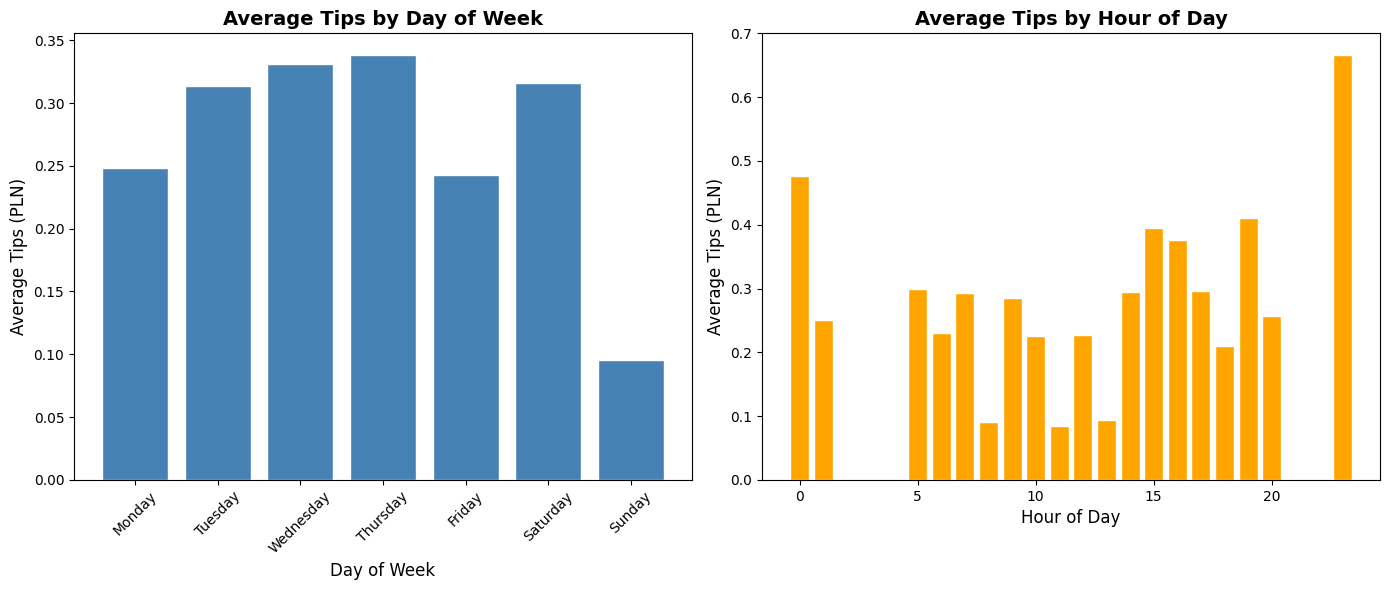

Tips Statistics:
Average tip per trip: 0.28 PLN
Trips with tips: 128 (4.7%)
Max tip received: 40.00 PLN
Total tips earned: 756.25 PLN


In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average tips per day of week
tips_by_day = df_earnings.groupby(
    df_earnings['request_time'].dt.day_name()
)['tips'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
])

axes[0].bar(tips_by_day.index, tips_by_day.values, 
            color='steelblue', edgecolor='white')
axes[0].set_title('Average Tips by Day of Week', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day of Week', fontsize=12)
axes[0].set_ylabel('Average Tips (PLN)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Average tips per hour
tips_by_hour = df_earnings.groupby(
    df_earnings['request_time'].dt.hour
)['tips'].mean()

axes[1].bar(tips_by_hour.index, tips_by_hour.values,
            color='orange', edgecolor='white')
axes[1].set_title('Average Tips by Hour of Day',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Average Tips (PLN)', fontsize=12)

plt.tight_layout()
plt.show()

# Statistics
print("Tips Statistics:")
print(f"Average tip per trip: {df_earnings['tips'].mean():.2f} PLN")
print(f"Trips with tips: {(df_earnings['tips'] > 0).sum()} ({(df_earnings['tips'] > 0).sum()/len(df_earnings)*100:.1f}%)")
print(f"Max tip received: {df_earnings['tips'].max():.2f} PLN")
print(f"Total tips earned: {df_earnings['tips'].sum():.2f} PLN")

Business Question 1: Which hours generate the highest earnings?

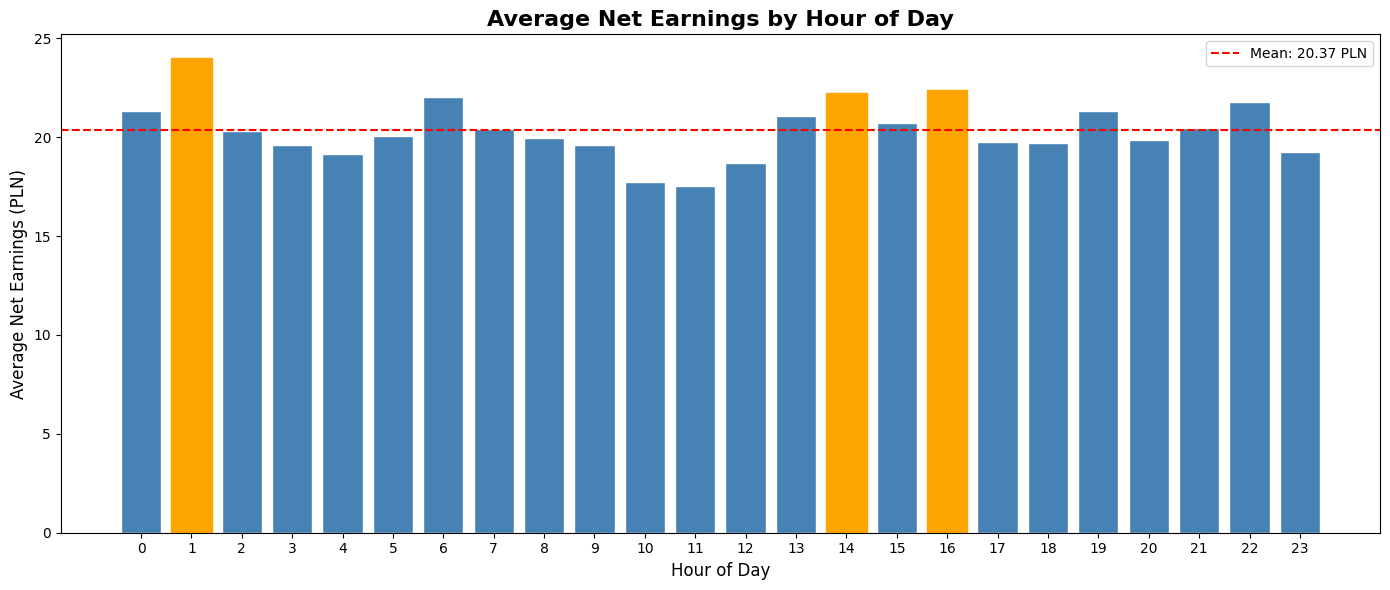

Top 5 Most Profitable Hours:
   hour  total_trips  avg_net_earnings_no_tips
0     1            8                 23.997500
1    16          348                 22.384224
2    14          205                 22.246878
3     6          117                 22.029829
4    22           19                 21.761053


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# which hour of the day is most profitable for Uber trips based on average net earnings (excluding tips)

# Sort by hour
hourly_revenue_gold = hourly_revenue_gold.sort_values('hour')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    hourly_revenue_gold['hour'],
    hourly_revenue_gold['avg_net_earnings_no_tips'],
    color='steelblue',
    edgecolor='white'
)

# Highlighting  top 3 hours
top_3 = hourly_revenue_gold.nlargest(3, 'avg_net_earnings_no_tips')['hour']
for bar, hour in zip(bars, hourly_revenue_gold['hour']):
    if hour in top_3.values:
        bar.set_color('orange')

# adding mean line to the plot to indicate the average net earnings across all hours for Uber trips.
mean_earnings = hourly_revenue_gold['avg_net_earnings_no_tips'].mean()
ax.axhline(y=mean_earnings, color='red', linestyle='--', 
           label=f'Mean: {mean_earnings:.2f} PLN')

# Labels
ax.set_title('Average Net Earnings by Hour of Day', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Net Earnings (PLN)', fontsize=12)
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.show()

# Printing the top 5 most profitable hours
print("Top 5 Most Profitable Hours:")
print(hourly_revenue_gold.nlargest(5, 'avg_net_earnings_no_tips')[
    ['hour', 'total_trips', 'avg_net_earnings_no_tips']
].reset_index(drop=True).to_string())

Business Question 2: Which day of the week is most profitable?

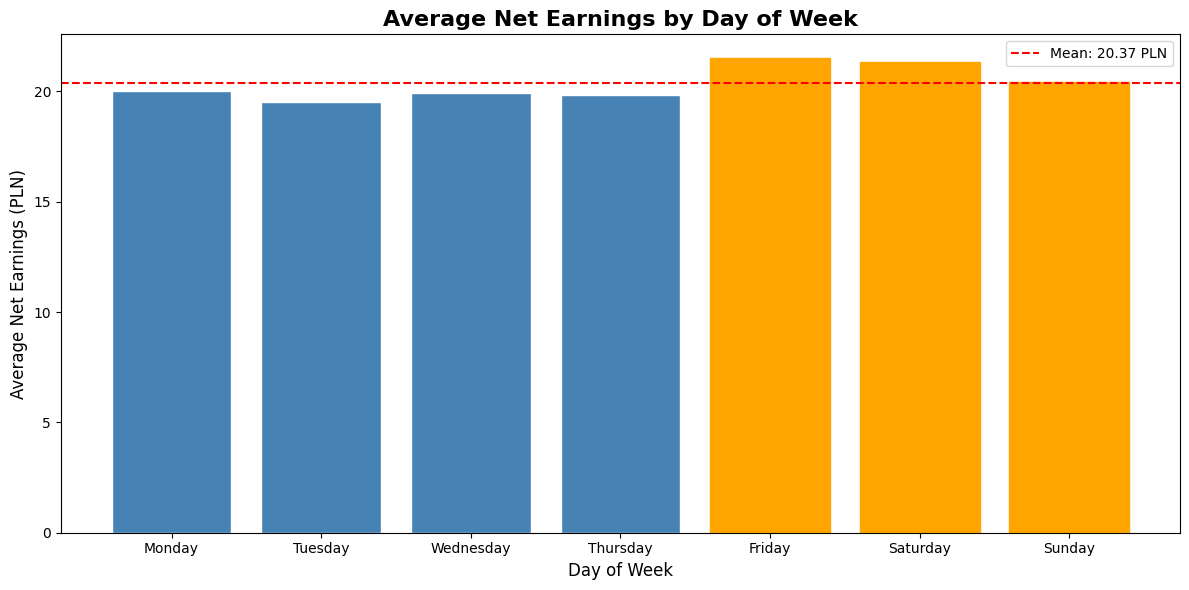

Days Ranked by Average Earnings:
    week_day  total_trips  avg_net_earnings_no_tips
0     Friday          486                 21.513395
1   Saturday          709                 21.350959
2     Sunday          282                 20.424291
3     Monday          334                 20.006527
4  Wednesday          303                 19.948317
5   Thursday          319                 19.859310
6    Tuesday          306                 19.512647


In [ ]:
# defining the order of days for plotting purposes to ensure that the days are displayed in the correct sequence on the plot.
day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# sorting by day order to ensure the days are displayed in the correct sequence on the plot.
day_of_week_revenue_gold['week_day'] = pd.Categorical(
    day_of_week_revenue_gold['week_day'], 
    categories=day_order, 
    ordered=True
)
day_of_week_revenue_gold = day_of_week_revenue_gold.sort_values('week_day')

# plot
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    day_of_week_revenue_gold['week_day'],
    day_of_week_revenue_gold['avg_net_earnings_no_tips'],
    color='steelblue',
    edgecolor='white'
)

# Highlighting the  top 3 days
top_3 = day_of_week_revenue_gold.nlargest(3, 'avg_net_earnings_no_tips')['week_day']
for bar, day in zip(bars, day_of_week_revenue_gold['week_day']):
    if day in top_3.values:
        bar.set_color('orange')

# adding mean line to the plot to indicate the average net earnings across all days of the week for Uber trips.
mean_earnings = day_of_week_revenue_gold['avg_net_earnings_no_tips'].mean()
ax.axhline(y=mean_earnings, color='red', linestyle='--',
           label=f'Mean: {mean_earnings:.2f} PLN')

# labels
ax.set_title('Average Net Earnings by Day of Week', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Net Earnings (PLN)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Print ranking
print("Days Ranked by Average Earnings:")
print(day_of_week_revenue_gold[['week_day', 'total_trips', 
                         'avg_net_earnings_no_tips']]
      .sort_values('avg_net_earnings_no_tips', ascending=False)
      .reset_index(drop=True).to_string())

Business Question 3: What is weekly  total earnings?

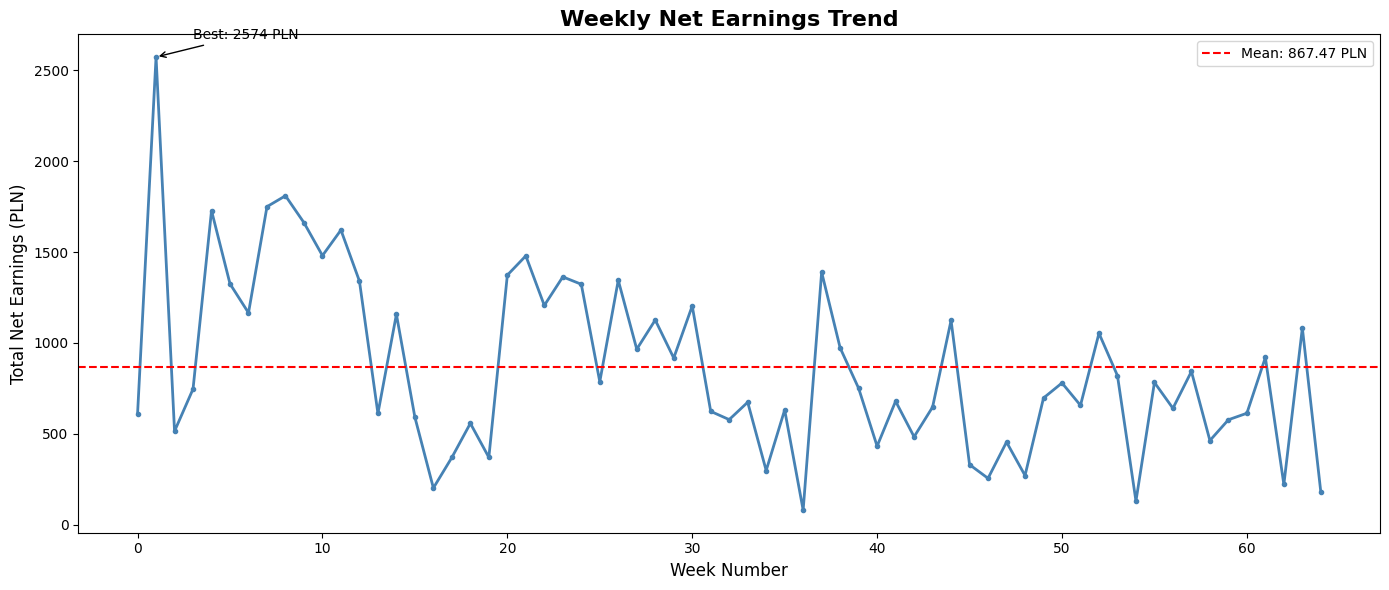

Weekly Earnings Summary:
Best Week:    2024-10-06 00:00:00 → 2573.58 PLN
Worst Week:   2025-06-22 00:00:00 → 79.80 PLN
Average Week: 867.47 PLN


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    range(len(weekly_revenue_gold)),
    weekly_revenue_gold['total_net_earnings_no_tips'],
    color='steelblue',
    linewidth=2,
    marker='o',
    markersize=3
)

# adding mean line to the plot to indicate the average net earnings across all weeks for Uber trips.
weekly_mean = weekly_revenue_gold['total_net_earnings_no_tips'].mean()
ax.axhline(y=weekly_mean, color='red', linestyle='--',
           label=f'Mean: {weekly_mean:.2f} PLN')

# annotatating the  best week
best_week_idx = weekly_revenue_gold['total_net_earnings_no_tips'].idxmax()
ax.annotate(
    f"Best: {weekly_revenue_gold.loc[best_week_idx, 'total_net_earnings_no_tips']:.0f} PLN",
    xy=(best_week_idx, weekly_revenue_gold.loc[best_week_idx, 'total_net_earnings_no_tips']),
    xytext=(best_week_idx + 2, weekly_revenue_gold.loc[best_week_idx, 'total_net_earnings_no_tips'] + 100),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)
#labels
ax.set_title('Weekly Net Earnings Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Week Number', fontsize=12)
ax.set_ylabel('Total Net Earnings (PLN)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Summary
print("Weekly Earnings Summary:")
print(f"Best Week:    {weekly_revenue_gold.loc[weekly_revenue_gold['total_net_earnings_no_tips'].idxmax(), 'week']} → {weekly_revenue_gold['total_net_earnings_no_tips'].max():.2f} PLN")
print(f"Worst Week:   {weekly_revenue_gold.loc[weekly_revenue_gold['total_net_earnings_no_tips'].idxmin(), 'week']} → {weekly_revenue_gold['total_net_earnings_no_tips'].min():.2f} PLN")
print(f"Average Week: {weekly_mean:.2f} PLN")

Business Question 4: Which month of the year is most profitable?

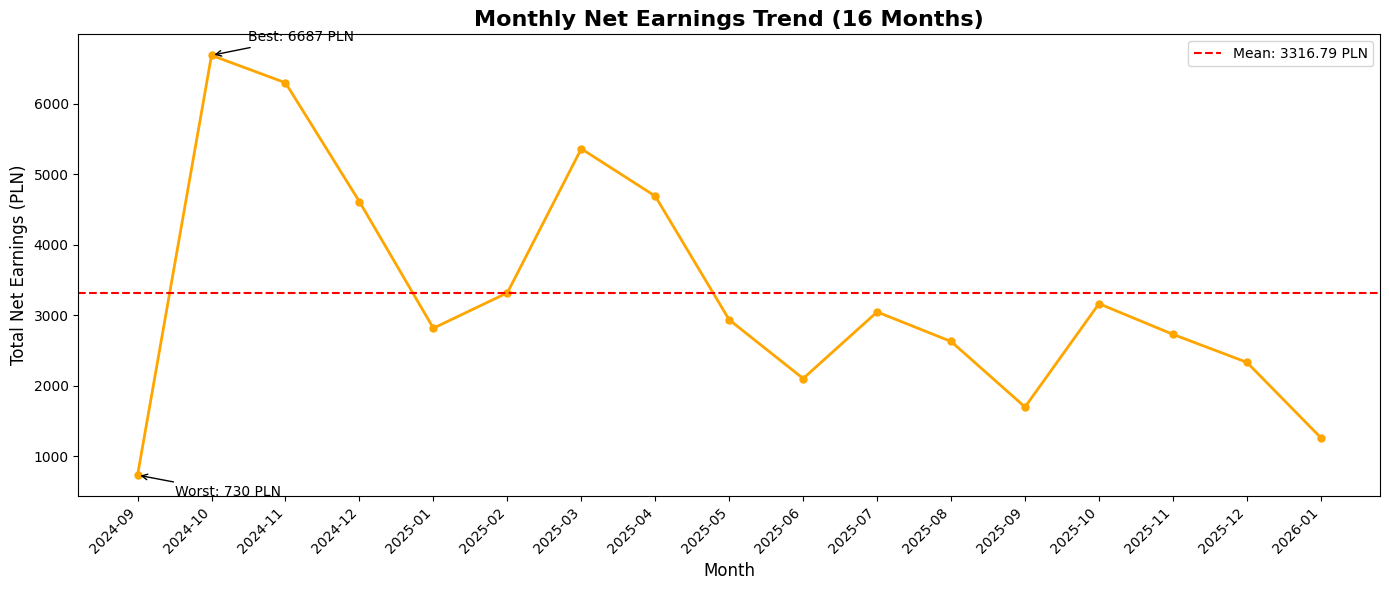

Monthly Earnings Summary:
Best Month:    2024-10 → 6687.10 PLN
Worst Month:   2024-09 → 729.68 PLN
Average Month: 3316.79 PLN

All Months Ranked:
   year_month  total_trips  total_net_earnings_no_tips
0     2024-10          337                     6687.10
1     2024-11          297                     6297.47
2     2025-03          271                     5361.18
3     2025-04          242                     4688.64
4     2024-12          217                     4610.39
5     2025-02          185                     3316.61
6     2025-10          140                     3162.23
7     2025-07          151                     3045.14
8     2025-05          138                     2933.55
9     2025-01          127                     2814.51
10    2025-11          127                     2727.19
11    2025-08          122                     2626.03
12    2025-12          102                     2329.94
13    2025-06          111                     2100.15
14    2025-09           72   

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    range(len(yearly_monthly_revenue_gold)),
    yearly_monthly_revenue_gold['total_net_earnings_no_tips'],
    color='orange',
    linewidth=2,
    marker='o',
    markersize=5
)

# Add mean line
monthly_mean = yearly_monthly_revenue_gold['total_net_earnings_no_tips'].mean()
ax.axhline(y=monthly_mean, color='red', linestyle='--',
           label=f'Mean: {monthly_mean:.2f} PLN')

# Add month labels
ax.set_xticks(range(len(yearly_monthly_revenue_gold)))
ax.set_xticklabels(
    yearly_monthly_revenue_gold['year_month'],
    rotation=45,
    ha='right'
)

# Annotate best month
best_month_idx = yearly_monthly_revenue_gold['total_net_earnings_no_tips'].idxmax()
ax.annotate(
    f"Best: {yearly_monthly_revenue_gold.loc[best_month_idx, 'total_net_earnings_no_tips']:.0f} PLN",
    xy=(best_month_idx, yearly_monthly_revenue_gold.loc[best_month_idx, 'total_net_earnings_no_tips']),
    xytext=(best_month_idx + 0.5, yearly_monthly_revenue_gold.loc[best_month_idx, 'total_net_earnings_no_tips'] + 200),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)

# Annotate worst month
worst_month_idx = yearly_monthly_revenue_gold['total_net_earnings_no_tips'].idxmin()
ax.annotate(
    f"Worst: {yearly_monthly_revenue_gold.loc[worst_month_idx, 'total_net_earnings_no_tips']:.0f} PLN",
    xy=(worst_month_idx, yearly_monthly_revenue_gold.loc[worst_month_idx, 'total_net_earnings_no_tips']),
    xytext=(worst_month_idx + 0.5, yearly_monthly_revenue_gold.loc[worst_month_idx, 'total_net_earnings_no_tips'] - 300),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)

ax.set_title('Monthly Net Earnings Trend (16 Months)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Net Earnings (PLN)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Summary
print("Monthly Earnings Summary:")
print(f"Best Month:    {yearly_monthly_revenue_gold.loc[best_month_idx, 'year_month']} → {yearly_monthly_revenue_gold['total_net_earnings_no_tips'].max():.2f} PLN")
print(f"Worst Month:   {yearly_monthly_revenue_gold.loc[worst_month_idx, 'year_month']} → {yearly_monthly_revenue_gold['total_net_earnings_no_tips'].min():.2f} PLN")
print(f"Average Month: {monthly_mean:.2f} PLN")
print(f"\nAll Months Ranked:")
print(yearly_monthly_revenue_gold[['year_month', 'total_trips', 
                                    'total_net_earnings_no_tips']]
      .sort_values('total_net_earnings_no_tips', ascending=False)
      .reset_index(drop=True).to_string())

Business Question 5: Which month of the year is most profitable?

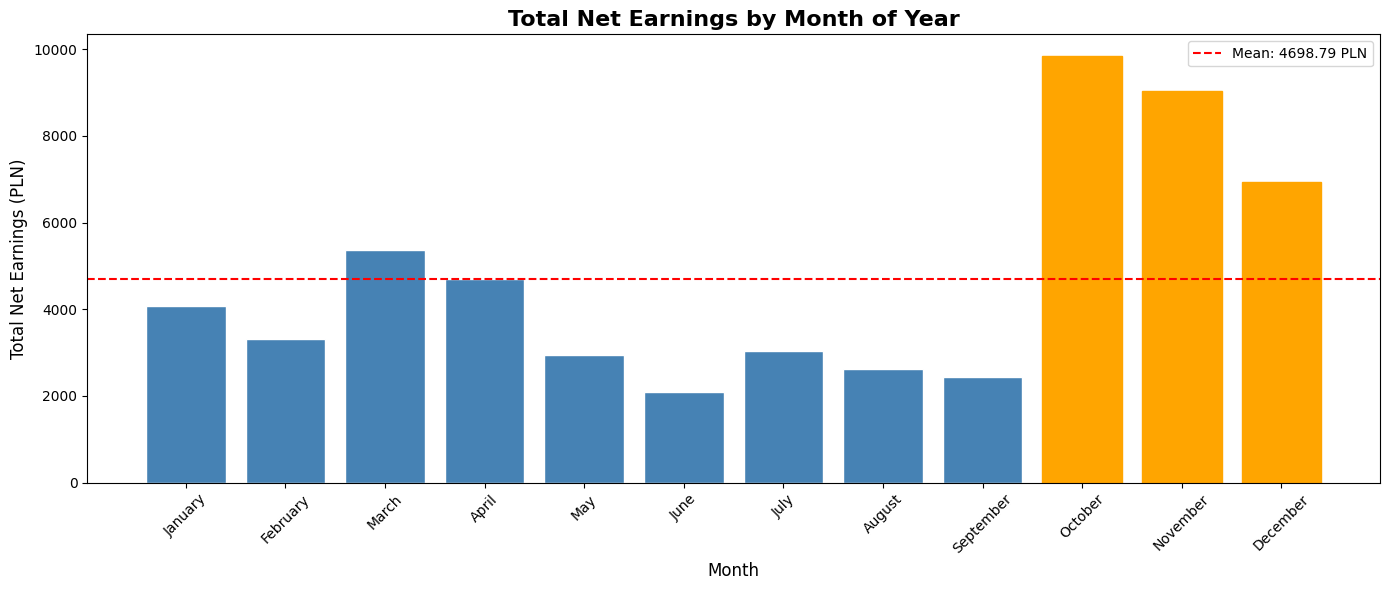

Months Ranked by Total Earnings:
   month_name  total_trips  total_net_earnings_no_tips
0     October          477                     9849.33
1    November          424                     9024.66
2    December          319                     6940.33
3       March          271                     5361.18
4       April          242                     4688.64
5     January          186                     4074.52
6    February          185                     3316.61
7        July          151                     3045.14
8         May          138                     2933.55
9      August          122                     2626.03
10  September          113                     2425.36
11       June          111                     2100.15


In [ ]:
# Map month numbers to names
month_names = {
    1: 'January', 2: 'February', 3: 'March',
    4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September',
    10: 'October', 11: 'November', 12: 'December'
}

monthly_revenue_gold['month_name'] = monthly_revenue_gold['month'].map(month_names)

# Define correct order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_revenue_gold['month_name'] = pd.Categorical(
    monthly_revenue_gold['month_name'],
    categories=month_order,
    ordered=True
)

monthly_revenue_gold = monthly_revenue_gold.sort_values('month_name')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    monthly_revenue_gold['month_name'],
    monthly_revenue_gold['total_net_earnings_no_tips'],
    color='steelblue',
    edgecolor='white'
)

# Highlight top 3 months
top_3 = monthly_revenue_gold.nlargest(3, 'total_net_earnings_no_tips')['month_name']
for bar, month in zip(bars, monthly_revenue_gold['month_name']):
    if month in top_3.values:
        bar.set_color('orange')

# Add mean line
monthly_mean = monthly_revenue_gold['total_net_earnings_no_tips'].mean()
ax.axhline(y=monthly_mean, color='red', linestyle='--',
           label=f'Mean: {monthly_mean:.2f} PLN')

ax.set_title('Total Net Earnings by Month of Year',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Net Earnings (PLN)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# Print ranking
print("Months Ranked by Total Earnings:")
print(monthly_revenue_gold[['month_name', 'total_trips',
                             'total_net_earnings_no_tips']]
      .sort_values('total_net_earnings_no_tips', ascending=False)
      .reset_index(drop=True).to_string())

Business Question 6: What is the average Uber deduction rate per trip?

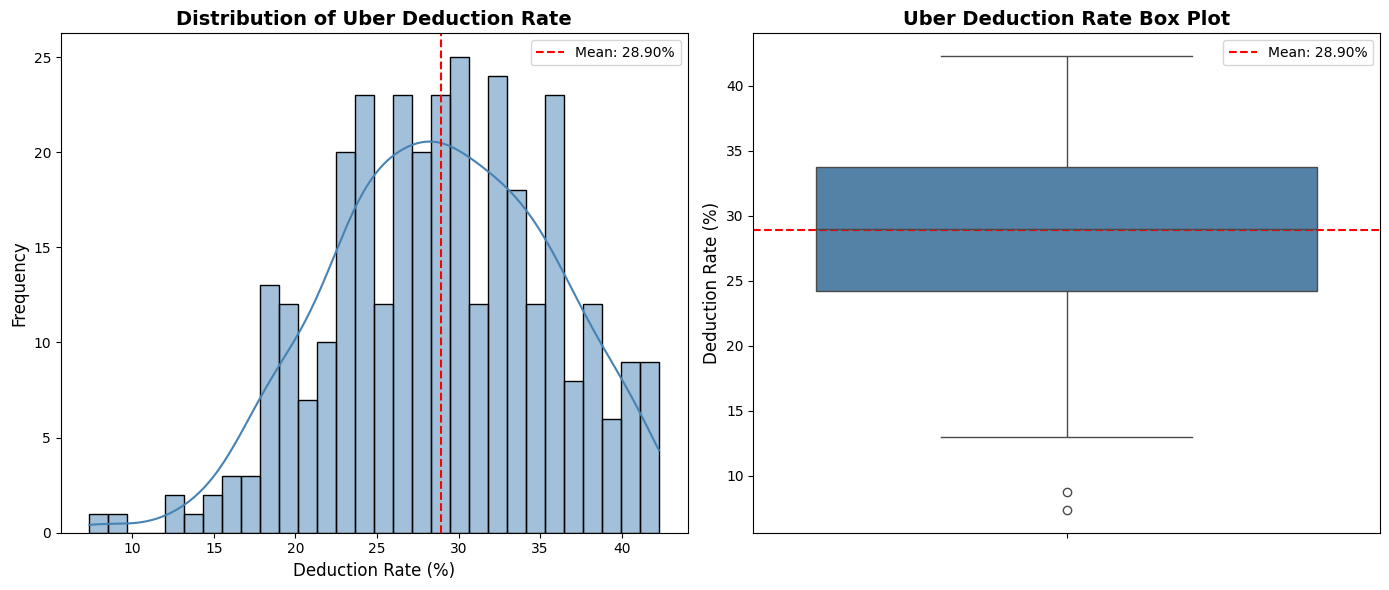

Uber Deduction Rate Statistics:
count    334.00
mean      28.90
std        6.70
min        7.37
25%       24.21
50%       29.00
75%       33.75
max       42.28
Name: uber_deduction_%, dtype: float64

Days above 35% deduction: 72
Days below 20% deduction: 36
Days with negative deduction: 0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
sns.histplot(
    daily_revenue_gold['uber_deduction_%'],
    bins=30,
    kde=True,
    ax=axes[0],
    color='steelblue'
)
axes[0].axvline(
    x=daily_revenue_gold['uber_deduction_%'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {daily_revenue_gold['uber_deduction_%'].mean():.2f}%"
)
axes[0].set_title('Distribution of Uber Deduction Rate',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Deduction Rate (%)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Box Plot
sns.boxplot(
    y=daily_revenue_gold['uber_deduction_%'],
    ax=axes[1],
    color='steelblue'
)
axes[1].axhline(
    y=daily_revenue_gold['uber_deduction_%'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {daily_revenue_gold['uber_deduction_%'].mean():.2f}%"
)
axes[1].set_title('Uber Deduction Rate Box Plot',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Deduction Rate (%)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics
print("Uber Deduction Rate Statistics:")
print(daily_revenue_gold['uber_deduction_%'].describe().round(2))
print(f"\nDays above 35% deduction: {(daily_revenue_gold['uber_deduction_%'] > 35).sum()}")
print(f"Days below 20% deduction: {(daily_revenue_gold['uber_deduction_%'] < 20).sum()}")
print(f"Days with negative deduction: {(daily_revenue_gold['uber_deduction_%'] < 0).sum()}")

Business Question 7: What is average earnings per km?

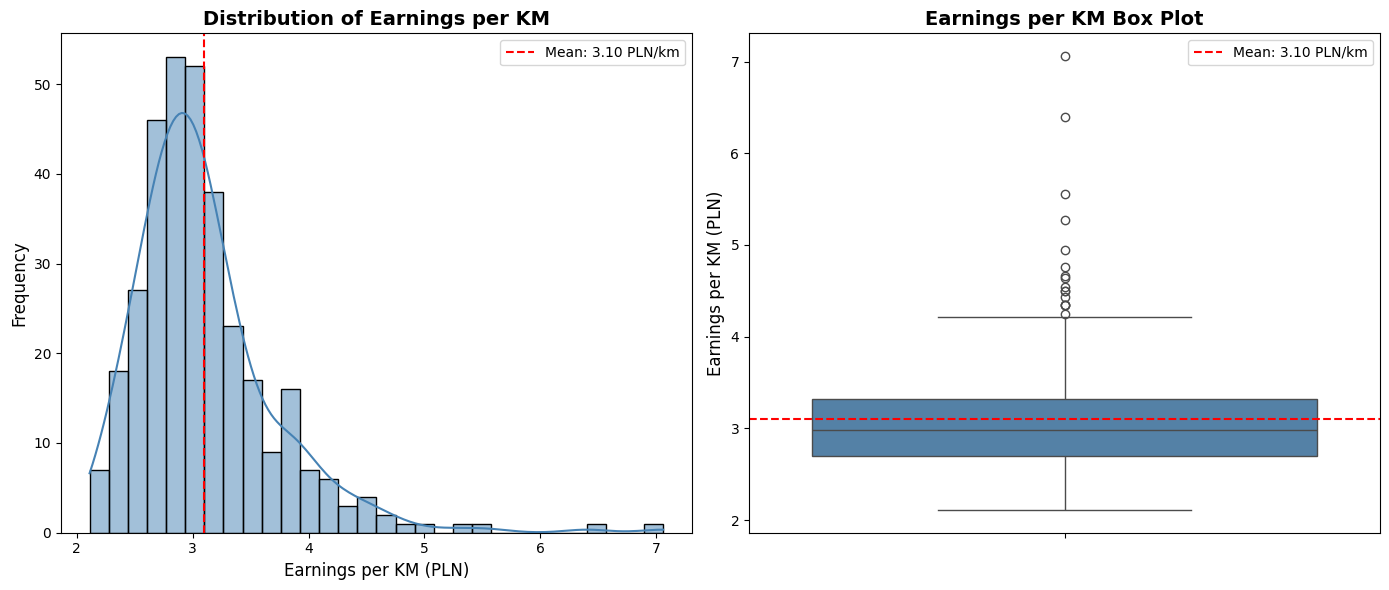

Earnings per KM Statistics:
count    334.00
mean       3.10
std        0.62
min        2.11
25%        2.70
50%        2.99
75%        3.32
max        7.06
Name: earnings_per_km, dtype: float64

Days above 4 PLN/km: 25
Days below 2.5 PLN/km: 36


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
sns.histplot(
    daily_revenue_gold['earnings_per_km'],
    bins=30,
    kde=True,
    ax=axes[0],
    color='steelblue'
)
axes[0].axvline(
    x=daily_revenue_gold['earnings_per_km'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {daily_revenue_gold['earnings_per_km'].mean():.2f} PLN/km"
)
axes[0].set_title('Distribution of Earnings per KM',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Earnings per KM (PLN)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Box Plot
sns.boxplot(
    y=daily_revenue_gold['earnings_per_km'],
    ax=axes[1],
    color='steelblue'
)
axes[1].axhline(
    y=daily_revenue_gold['earnings_per_km'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {daily_revenue_gold['earnings_per_km'].mean():.2f} PLN/km"
)
axes[1].set_title('Earnings per KM Box Plot',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Earnings per KM (PLN)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics
print("Earnings per KM Statistics:")
print(daily_revenue_gold['earnings_per_km'].describe().round(2))
print(f"\nDays above 4 PLN/km: {(daily_revenue_gold['earnings_per_km'] > 4).sum()}")
print(f"Days below 2.5 PLN/km: {(daily_revenue_gold['earnings_per_km'] < 2.5).sum()}")

Business Question 8: How has monthly revenue trended over 16 months?

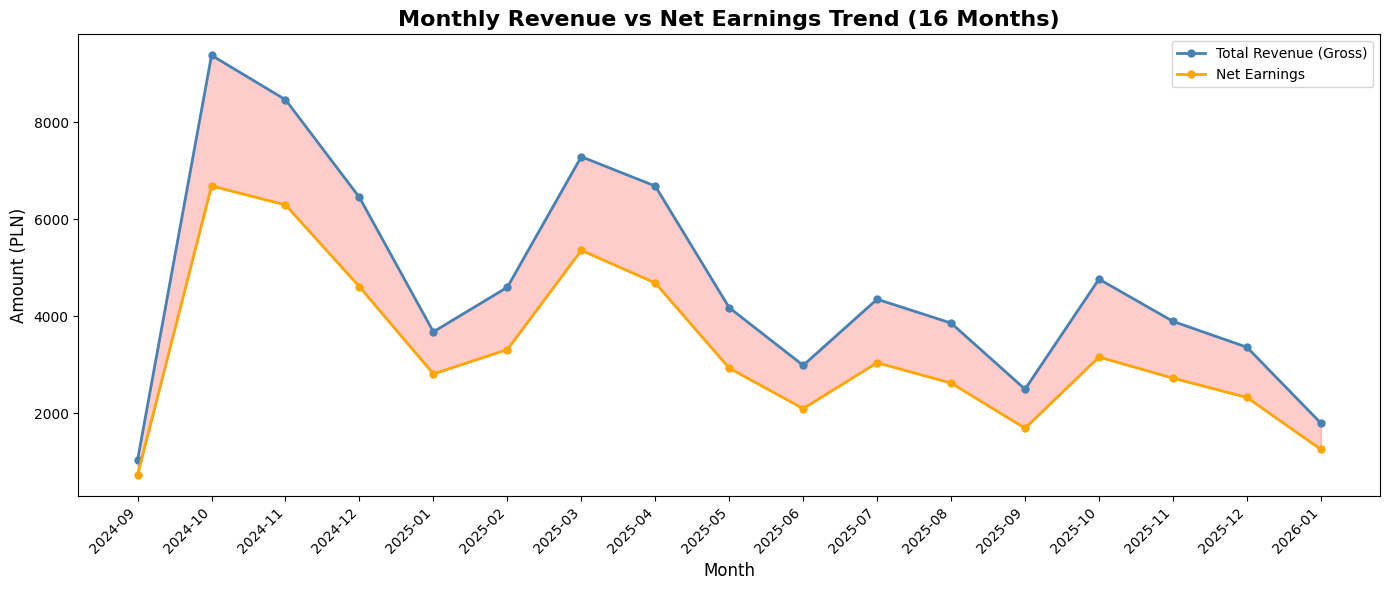

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Total Revenue line
ax.plot(
    range(len(yearly_monthly_revenue_gold)),
    yearly_monthly_revenue_gold['total_revenue'],
    color='steelblue',
    linewidth=2,
    marker='o',
    markersize=5,
    label='Total Revenue (Gross)'
)

# Net Earnings line
ax.plot(
    range(len(yearly_monthly_revenue_gold)),
    yearly_monthly_revenue_gold['total_net_earnings_no_tips'],
    color='orange',
    linewidth=2,
    marker='o',
    markersize=5,
    label='Net Earnings'
)

# Month labels
ax.set_xticks(range(len(yearly_monthly_revenue_gold)))
ax.set_xticklabels(
    yearly_monthly_revenue_gold['year_month'],
    rotation=45,
    ha='right'
)

ax.set_title('Monthly Revenue vs Net Earnings Trend (16 Months)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Amount (PLN)', fontsize=12)
ax.legend()
ax.fill_between(
    range(len(yearly_monthly_revenue_gold)),
    yearly_monthly_revenue_gold['total_net_earnings_no_tips'],
    yearly_monthly_revenue_gold['total_revenue'],
    alpha=0.2,
    color='red',
    label='Uber Deduction'
)

plt.tight_layout()
plt.show()

Business Question 9: Which hours have the highest trip demand?

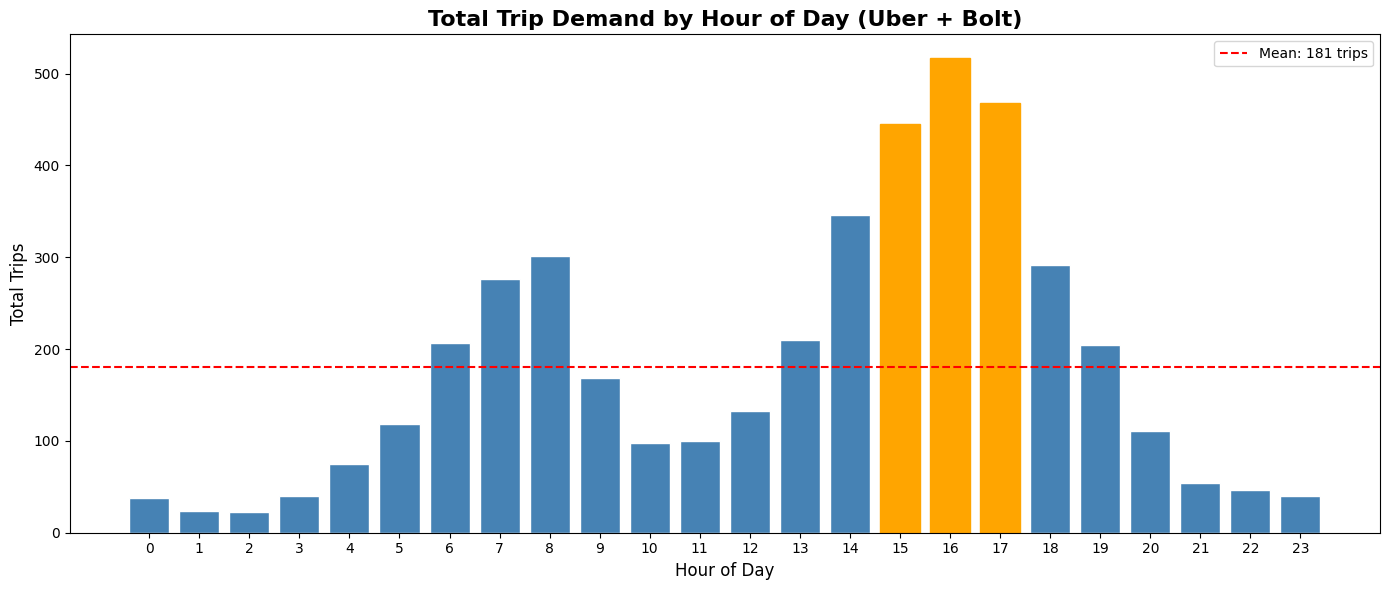

Top 5 Busiest Hours:
   hour  total_trips
0    16          517
1    17          468
2    15          445
3    14          346
4     8          301

Bottom 5 Quietest Hours:
   hour  total_trips
0     2           23
1     1           24
2     0           38
3     3           40
4    23           40


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    hourly_demand_gold['hour'],
    hourly_demand_gold['total_trips'],
    color='steelblue',
    edgecolor='white'
)

# Highlight top 3 hours
top_3 = hourly_demand_gold.nlargest(3, 'total_trips')['hour']
for bar, hour in zip(bars, hourly_demand_gold['hour']):
    if hour in top_3.values:
        bar.set_color('orange')

# Add mean line
mean_trips = hourly_demand_gold['total_trips'].mean()
ax.axhline(y=mean_trips, color='red', linestyle='--',
           label=f'Mean: {mean_trips:.0f} trips')

ax.set_title('Total Trip Demand by Hour of Day (Uber + Bolt)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Total Trips', fontsize=12)
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.show()

# Print ranking
print("Top 5 Busiest Hours:")
print(hourly_demand_gold.nlargest(5, 'total_trips')[
    ['hour', 'total_trips']
].reset_index(drop=True).to_string())

print("\nBottom 5 Quietest Hours:")
print(hourly_demand_gold.nsmallest(5, 'total_trips')[
    ['hour', 'total_trips']
].reset_index(drop=True).to_string())

Business Question 10: Which day has the highest trip volume?

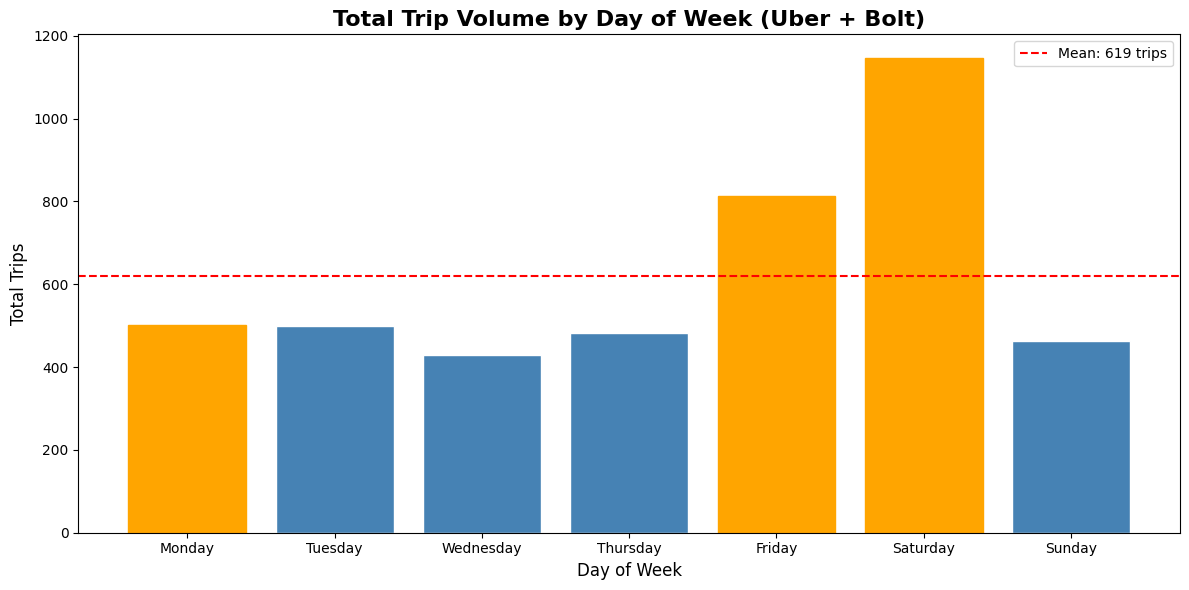

Days Ranked by Trip Volume:
  day_of_week  total_trips
0    Saturday         1146
1      Friday          814
2      Monday          501
3     Tuesday          499
4    Thursday          481
5      Sunday          464
6   Wednesday          430


In [ ]:
# Define correct day order
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# Sort by day order
daily_demand_gold['day_of_week'] = pd.Categorical(
    daily_demand_gold['day_of_week'],
    categories=day_order,
    ordered=True
)
daily_demand_gold = daily_demand_gold.sort_values('day_of_week')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    daily_demand_gold['day_of_week'],
    daily_demand_gold['total_trips'],
    color='steelblue',
    edgecolor='white'
)

# Highlight top 3 days
top_3 = daily_demand_gold.nlargest(3, 'total_trips')['day_of_week']
for bar, day in zip(bars, daily_demand_gold['day_of_week']):
    if day in top_3.values:
        bar.set_color('orange')

# Add mean line
mean_trips = daily_demand_gold['total_trips'].mean()
ax.axhline(y=mean_trips, color='red', linestyle='--',
           label=f'Mean: {mean_trips:.0f} trips')

ax.set_title('Total Trip Volume by Day of Week (Uber + Bolt)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Total Trips', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Print ranking
print("Days Ranked by Trip Volume:")
print(daily_demand_gold[['day_of_week', 'total_trips']]
      .sort_values('total_trips', ascending=False)
      .reset_index(drop=True).to_string())

Business Question 11: During which seasons is demand highest?

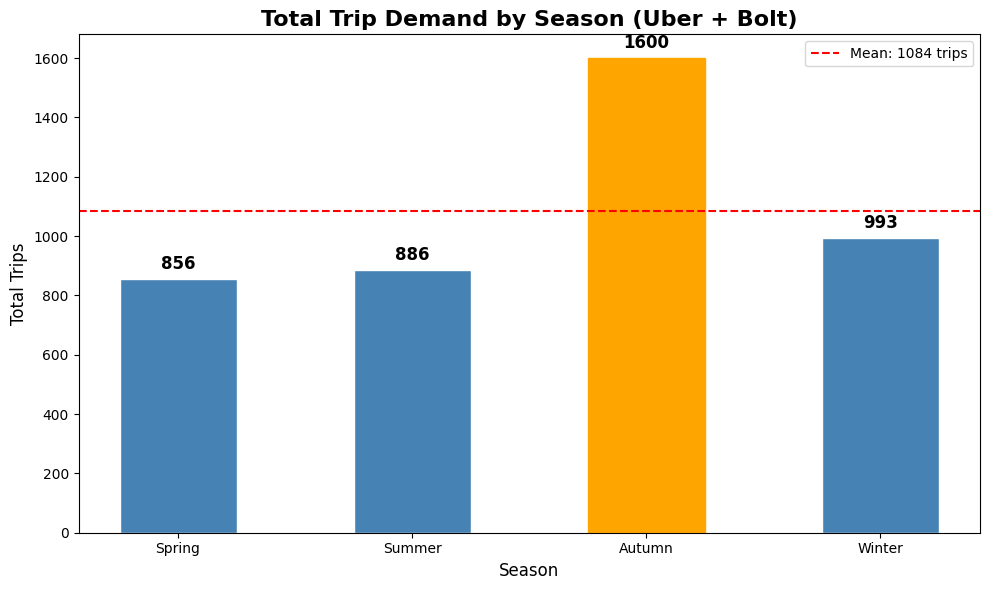

Seasonal Demand Summary:
   season  total_trips  avg_distance  avg_duration
0  Autumn         1600   6707.945806   1020.928750
1  Winter          993   6622.565217    996.633434
2  Summer          886   6623.952698    957.566591
3  Spring          856   6676.806893    975.552570


In [ ]:
# Define season order
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

seasonal_demand_gold['season'] = pd.Categorical(
    seasonal_demand_gold['season'],
    categories=season_order,
    ordered=True
)
seasonal_demand_gold = seasonal_demand_gold.sort_values('season')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    seasonal_demand_gold['season'],
    seasonal_demand_gold['total_trips'],
    color='steelblue',
    edgecolor='white',
    width=0.5
)

# Highlight top season
top_1 = seasonal_demand_gold.nlargest(1, 'total_trips')['season']
for bar, season in zip(bars, seasonal_demand_gold['season']):
    if season in top_1.values:
        bar.set_color('orange')

# Add mean line
mean_trips = seasonal_demand_gold['total_trips'].mean()
ax.axhline(y=mean_trips, color='red', linestyle='--',
           label=f'Mean: {mean_trips:.0f} trips')

# Add value labels on bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{int(bar.get_height())}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

ax.set_title('Total Trip Demand by Season (Uber + Bolt)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Total Trips', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Print summary
print("Seasonal Demand Summary:")
print(seasonal_demand_gold[['season', 'total_trips',
                             'avg_distance', 'avg_duration']]
      .sort_values('total_trips', ascending=False)
      .reset_index(drop=True).to_string())

## Data Quality Decision — Cancelled Trips

48 cancelled trips with zero distance and duration were identified 
in the ML Earnings Features table.

**Decision:** Remove from ML tables only — keep in revenue tables.

**Reason:** 
- Cancellation fees are legitimate earnings → retained in 
  daily/weekly/monthly revenue tables
- Zero distance and duration values provide no meaningful 
  trip characteristic signal for ML model → removed from 
  ML_Earnings_Features and ML_Demand_Features

**Records affected:** 48 rows (1.75% of total ML records)

Business Question 12: Can historical patterns predict High/Medium/Low demand periods?

In [ ]:

# Remove cancelled trips
df_demand = df_demand[
    (df_demand['distance'] > 0) &
    (df_demand['duration'] > 0)
].reset_index(drop=True)

print(f"Dataset shape: {df_demand.shape}")

Dataset shape: (4287, 10)


In [ ]:

#remove cancelled trips
df_demand = df_demand[
    (df_demand['distance']> 0) &
    (df_demand['duration'] > 0)].reset_index(drop=True)

def demand_score(hour,day,season):
    score = 0
    # Hourly scoring
    if hour in  [14,15,16,17,7,8]:
        score += 3 # peak hours
    elif hour in [0,1,2,3,4,21,22,23]:
        score +=0 # quiet hours
    else:
        score += 1 # normal hours

    # Day of week scoring
    if day in  ['Friday', 'Saturday']:
        score += 2 # busy days
    elif day in ['Wednesday']:
        score += 0 # quiet days
    else: 
        score +=1 #normal days

    # Seasonal scoring
    if season in ['Autumn','Winter' ]:
        score += 2 # high demand seasons
    
    else:
        score += 0 #quiet season
    return score

# applying the score
df_demand['demand_score'] = df_demand.apply(
    lambda x: demand_score(x['hour'],x['day_of_week'],x['season']), axis=1)

# assigning demand category
def assign_demand_from_score(score):
    if score <= 2:
        return 'Low'
    elif score <= 5:
        return 'Medium'
    else:
        return 'High'
    
df_demand['demand_category'] = df_demand['demand_score'].apply(assign_demand_from_score)

print(f"\n Demand Category Distribution:")
print(df_demand['demand_category'].value_counts())
print(f"\nPercentage:")
print(df_demand['demand_category'].value_counts(normalize=True).round(3)*100)


df_demand.to_sql('ML_Demand', engine, schema='Gold', if_exists='replace', index=False) 

    




 Demand Category Distribution:
demand_category
Medium    2578
High      1231
Low        478
Name: count, dtype: int64

Percentage:
demand_category
Medium    60.1
High      28.7
Low       11.1
Name: proportion, dtype: float64


111

Business Question 13: Can historical patterns predict High/Medium/Low earning periods?

In [ ]:
# Extracting time features
df_earnings  = df_earnings[(df_earnings['distance_metres'] > 0)&
                           (df_earnings['duration_seconds']>0)]

df_earnings['date'] = df_earnings['request_time'].dt.date
df_earnings['hour'] = df_earnings['request_time'].dt.hour
df_earnings['day_of_week'] = df_earnings['request_time'].dt.day_name()
df_earnings['month'] = df_earnings['request_time'].dt.month
df_earnings['season'] = df_earnings['month'].map({
    12: 'Winter', 1: 'Winter', 2:'Winter',
      3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# adding demand score

def demand_score(hour, day, season):
    score = 0
    if hour in [14, 15, 16, 17, 7, 8]:
        score += 3
    elif hour in [0, 1, 2, 3, 4, 21, 22, 23]:
        score += 0
    else:
        score += 1
    if day in ['Friday', 'Saturday']:
        score += 2
    elif day in ['Wednesday']:
        score += 0
    else:
        score += 1
    if season in ['Autumn']:
        score += 2
    elif season in ['Winter']:
        score += 1
    else:
        score += 0
    return score

df_earnings['demand_score'] = df_earnings.apply(
    lambda x: demand_score(
        x['hour'], x['day_of_week'], x['season']
    ), axis=1
)


# calculating total earnings per hour per day

hourly_earnings = df_earnings.groupby(
    ['date', 'hour']
)['net_earnings_no_tips'].sum().reset_index()
hourly_earnings.rename(
    columns={'net_earnings_no_tips': 'hourly_earnings'}, inplace=True)

# defining the thresholds
low_threshold = hourly_earnings['hourly_earnings'].quantile(0.33)
high_threshold = hourly_earnings['hourly_earnings'].quantile(0.66)

# assigning earning categories based on thresholds
def assign_earning_category(earnings):
    if earnings < low_threshold:
        return 'Low'
    elif earnings < high_threshold:
        return 'Medium'
    else:
        return 'High'

print(f"Low threshold:  {low_threshold:.2f}")
print(f"High threshold: {high_threshold:.2f}")
hourly_earnings['earning_category'] = hourly_earnings['hourly_earnings'].apply(assign_earning_category)
df_earnings = df_earnings.merge(hourly_earnings[['date', 'hour', 'hourly_earnings', 'earning_category']], on=['date', 'hour'], how='left')

# keeping only the relevant columns for machine learning model
df_ml_earnings = df_earnings[['request_time','hour', 'day_of_week', 'month','season', 'distance_metres', 'duration_seconds',  'earning_category','hourly_earnings']]



Low threshold:  26.14
High threshold: 33.18


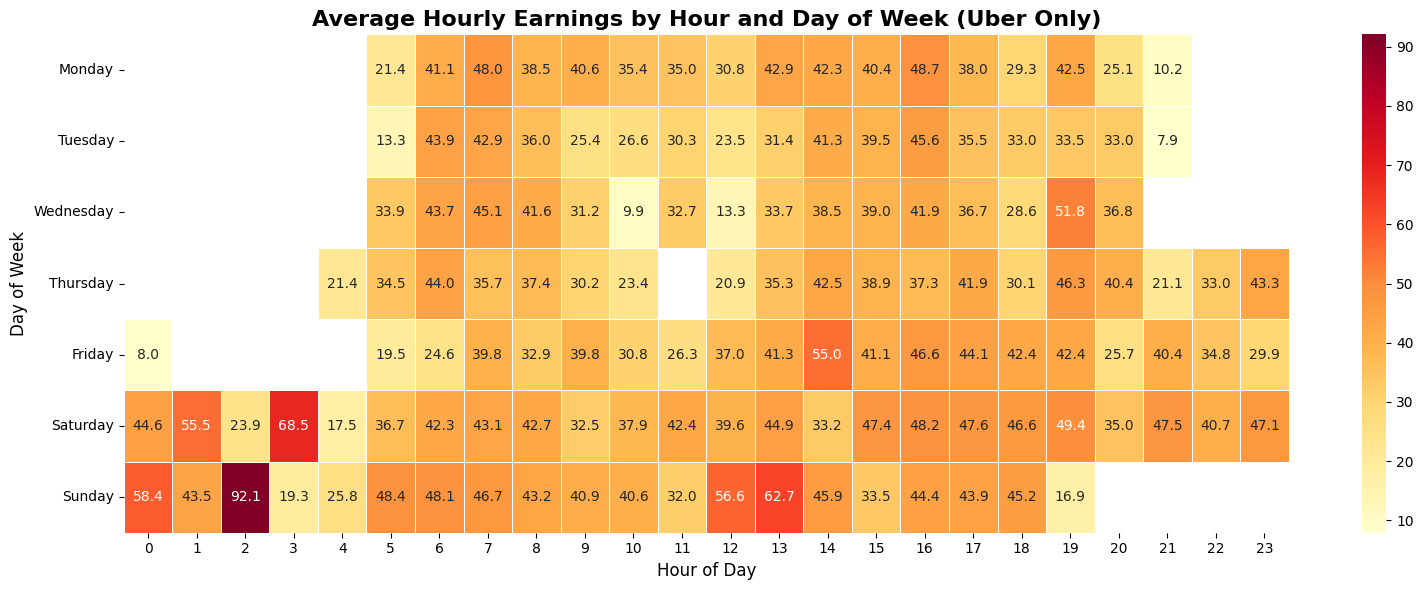

In [ ]:
# Create pivot table — hour vs day of week for earnings
pivot_earnings = df_ml_earnings.groupby(
    ['day_of_week', 'hour']
)['hourly_earnings'].mean().unstack()

# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_earnings = pivot_earnings.reindex(day_order)

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    pivot_earnings,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)

ax.set_title('Average Hourly Earnings by Hour and Day of Week (Uber Only)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Check your daily earnings distribution
Q1 = daily_revenue_gold['total_net_earnings_no_tips'].quantile(0.25)
Q3 = daily_revenue_gold['total_net_earnings_no_tips'].quantile(0.75)
IQR = Q3 - Q1

# Upper outlier threshold
upper_threshold = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f} PLN")
print(f"Q3: {Q3:.2f} PLN")
print(f"IQR: {IQR:.2f} PLN")
print(f"Upper outlier threshold: {upper_threshold:.2f} PLN")

# Show outlier days
outlier_days = daily_revenue_gold[
    daily_revenue_gold['total_net_earnings_no_tips'] > upper_threshold
][['date', 'total_trips', 'total_net_earnings_no_tips']]

print(f"\nTotal outlier days: {len(outlier_days)}")
print(outlier_days.to_string())

Q1: 79.97 PLN
Q3: 225.11 PLN
IQR: 145.14 PLN
Upper outlier threshold: 442.82 PLN

Total outlier days: 12
          date  total_trips  total_net_earnings_no_tips
5   2024-10-02           22                      497.26
7   2024-10-04           25                      512.90
8   2024-10-05           28                      554.20
22  2024-10-26           27                      513.44
27  2024-10-31           25                      509.62
33  2024-11-09           23                      444.46
39  2024-11-16           23                      495.05
53  2024-11-30           19                      527.66
59  2024-12-07           25                      552.33
117 2025-03-01           18                      451.44
172 2025-05-02           20                      452.44
281 2025-10-18           24                      445.45


In [ ]:


# Verified event dates
event_dates = [
    '2024-10-02',  # University semester start
    '2024-10-04',  # First Friday academic year
    '2024-10-05',  # Kamil Bednarek — Atlas Arena
    '2024-10-26',  # Multi-event Saturday
    '2024-10-31',  # Halloween + volleyball
    '2024-11-09',  # Sum 41 — Atlas Arena
    '2024-11-16',  # Dream Theater — Atlas Arena
    '2024-11-30',  # St Andrews Day + JIMEK
    '2024-12-07',  # St Nicholas Day
    '2025-03-01',  # Przedwiośnie party
    '2025-05-02',  # Majówka weekend
    '2025-10-18'   # Elektryczne Gitary — Atlas Arena
]

# Add date string column for matching
df_ml_earnings['date_str'] = df_ml_earnings[
    'request_time'].dt.date.astype(str).values

# Add binary event flag
df_ml_earnings['is_event_day'] = df_ml_earnings[
    'date_str'].isin(event_dates).astype(int)

# Dropping date_str 
df_ml_earnings = df_ml_earnings.drop(columns=['date_str'])

# Verify
print(f"Event day records: {df_ml_earnings['is_event_day'].sum()}")
print(f"Normal day records: {(df_ml_earnings['is_event_day']==0).sum()}")
print(f"\nFinal columns: {df_ml_earnings.columns.tolist()}")
print(f"\nAverage earnings — Event vs Normal:")
print(df_ml_earnings.groupby('is_event_day')[
    'hourly_earnings'].mean().round(2))

df_ml_earnings.to_sql('ML_Earnings', engine, schema='Gold', if_exists='replace', index=False)   

Event day records: 272
Normal day records: 2419

Final columns: ['request_time', 'hour', 'day_of_week', 'month', 'season', 'distance_metres', 'duration_seconds', 'earning_category', 'hourly_earnings', 'is_event_day']

Average earnings — Event vs Normal:
is_event_day
0    40.36
1    48.23
Name: hourly_earnings, dtype: float64


183

In [ ]:
# Extracting time features
df_earnings = df_earnings[
    (df_earnings['distance_metres'] > 0) &
    (df_earnings['duration_seconds'] > 0)
]

df_earnings['date'] = df_earnings['request_time'].dt.date
df_earnings['hour'] = df_earnings['request_time'].dt.hour
df_earnings['day_of_week'] = df_earnings['request_time'].dt.day_name()
df_earnings['month'] = df_earnings['request_time'].dt.month
df_earnings['season'] = df_earnings['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Add demand score
def calculate_demand_score(hour, day_of_week, season):
    score = 0
    if hour in [14, 15, 16, 17, 7, 8]:
        score += 3
    elif hour in [0, 1, 2, 3, 4, 21, 22, 23]:
        score += 0
    else:
        score += 1
    if day_of_week in ['Friday', 'Saturday']:
        score += 2
    elif day_of_week in ['Wednesday']:
        score += 0
    else:
        score += 1
    if season in ['Autumn']:
        score += 2
    elif season in ['Winter']:
        score += 1
    else:
        score += 0
    return score

df_earnings['demand_score'] = df_earnings.apply(
    lambda x: calculate_demand_score(
        x['hour'], x['day_of_week'], x['season']
    ), axis=1
)

# Add event flag
event_dates = [
    '2024-10-02', '2024-10-04', '2024-10-05',
    '2024-10-26', '2024-10-31', '2024-11-09',
    '2024-11-16', '2024-11-30', '2024-12-07',
    '2025-03-01', '2025-05-02', '2025-10-18'
]
df_earnings['is_event_day'] = df_earnings[
    'date'].astype(str).isin(event_dates).astype(int)

# Calculate hourly earnings
hourly_earnings = df_earnings.groupby(
    ['date', 'hour']
)['net_earnings_no_tips'].sum().reset_index()
hourly_earnings.rename(
    columns={'net_earnings_no_tips': 'hourly_earnings'}, inplace=True)

# Define thresholds
low_threshold = hourly_earnings['hourly_earnings'].quantile(0.33)
high_threshold = hourly_earnings['hourly_earnings'].quantile(0.66)

print(f"Low threshold:  {low_threshold:.2f}")
print(f"High threshold: {high_threshold:.2f}")

# Assign earning categories
def assign_earning_category(earnings):
    if earnings < low_threshold:
        return 'Low'
    elif earnings < high_threshold:
        return 'Medium'
    else:
        return 'High'

hourly_earnings['earning_category'] = hourly_earnings[
    'hourly_earnings'].apply(assign_earning_category)

# Merge back
df_earnings = df_earnings.merge(
    hourly_earnings[['date', 'hour', 'hourly_earnings', 'earning_category']],
    on=['date', 'hour'], how='left'
)

# Keep relevant columns only
df_ml_earnings = df_earnings[[
    'hour', 'day_of_week', 'month', 'season',
    'distance_metres', 'duration_seconds',
    'demand_score', 'is_event_day', 'earning_category'
]]

print(f"\nShape: {df_ml_earnings.shape}")
print(f"\nCategory distribution:")
print(df_ml_earnings['earning_category'].value_counts())
print(df_ml_earnings['earning_category'].value_counts(
    normalize=True).round(3) * 100)

Low threshold:  26.14
High threshold: 41.81


KeyError: "['earning_category'] not in index"